# CSCI 3151 — M01 Mini-lab

## ML in the wild: paradigms, decisions, and stakes

In this mini-lab, you will **spot machine learning systems in the wild** and connect them to:

- The **learning paradigm** (supervised, unsupervised, self-/semi-supervised),
- The **decision** they support,
- The **metric** and **errors** that matter.

The goal is not to be perfect, but to start thinking like an **ML engineer + scientist** about everyday systems.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 120)

systems = pd.DataFrame([
    {
        "system_name": "Spam filter",
        "description": "Classifies incoming emails as spam or not spam based on their content and metadata.",
        "has_labels": True,
        "stakes": "medium",
    },
    {
        "system_name": "Movie recommender",
        "description": "Suggests movies to watch next based on your viewing history and similar users.",
        "has_labels": True,
        "stakes": "low",
    },
    {
        "system_name": "Autonomous emergency braking",
        "description": "Detects imminent collisions and automatically applies the brakes.",
        "has_labels": True,
        "stakes": "high",
    },
    {
        "system_name": "Language model autocomplete",
        "description": "Predicts the next word or phrase as you type a message.",
        "has_labels": False,
        "stakes": "medium",
    },
    {
        "system_name": "Anomaly detection on server logs",
        "description": "Flags unusual patterns in logs that may indicate security incidents or failures.",
        "has_labels": False,
        "stakes": "high",
    },
    {
        "system_name": "Image search by visual similarity",
        "description": "Lets you search for images that 'look like' a query image.",
        "has_labels": False,
        "stakes": "low",
    },
])

print("Example ML-related systems:")
systems

Example ML-related systems:


,system_name,description,has_labels,stakes
0,Spam filter,Classifies incoming emails as spam or not spam based on their content and metadata.,True,medium
1,Movie recommender,Suggests movies to watch next based on your viewing history and similar users.,True,low
2,Autonomous emergency braking,Detects imminent collisions and automatically applies the brakes.,True,high
3,Language model autocomplete,Predicts the next word or phrase as you type a message.,False,medium
4,Anomaly detection on server logs,Flags unusual patterns in logs that may indicate security incidents or failures.,False,high
5,Image search by visual similarity,Lets you search for images that 'look like' a query image.,False,low


## Task 1 — Classify paradigms

For each system, assign the **learning paradigm** you think best describes how it is *mostly* trained:

- `"supervised"`
- `"unsupervised"`
- `"self-supervised"`
- `"semi-supervised"`

There is often more than one reasonable answer; aim for a good **argument**, not perfection.

👉 Fill in the list of paradigms in the next cell so that each row gets one value.

In [9]:
# === Task 1: fill in the 'paradigm' column ===============================

allowed_paradigms = {"supervised", "unsupervised", "self-supervised", "semi-supervised"}

# TODO: Replace the strings below with your guesses.
# There should be exactly ONE paradigm string for each system in the same order
# as the rows printed above.
systems["paradigm"] = [
    # e.g., "supervised",
    #       "self-supervised",
    #       ...
    "supervised",  # Spam filter
    "semi-supervised",  # Movie recommender
    "semi-supervised",  # Autonomous emergency braking
    "semi-supervised",  # Language model autocomplete
    "unsupervised",  # Anomaly detection on server logs
    "self-supervised",  # Image search by visual similarity
]

# Simple checks
assert len(systems["paradigm"]) == len(systems)
assert systems["paradigm"].notna().all(), "You must fill in all paradigms."
assert set(systems["paradigm"]).issubset(allowed_paradigms), "Use only allowed paradigm names."

systems

,system_name,description,has_labels,stakes,paradigm
0,Spam filter,Classifies incoming emails as spam or not spam based on their content and metadata.,True,medium,supervised
1,Movie recommender,Suggests movies to watch next based on your viewing history and similar users.,True,low,semi-supervised
2,Autonomous emergency braking,Detects imminent collisions and automatically applies the brakes.,True,high,semi-supervised
3,Language model autocomplete,Predicts the next word or phrase as you type a message.,False,medium,semi-supervised
4,Anomaly detection on server logs,Flags unusual patterns in logs that may indicate security incidents or failures.,False,high,unsupervised
5,Image search by visual similarity,Lets you search for images that 'look like' a query image.,False,low,self-supervised


## Task 2 — From predictions to decisions and metrics

Pick **one high-stakes system** (stakes = `"high"`) and think about:

- What is the **decision** that gets made using this model?
- What kind of **metric** would you want to look at?
- Which type of **error** worries you more, and why?

👉 Fill in the `decision` dictionary in the next cell for *one* chosen system.

In [16]:
# === Task 2: decisions & metrics =========================================

high_stakes = systems[systems["stakes"] == "high"].copy()
print("High-stakes systems:")
display(high_stakes)

# Choose one row index from high_stakes.index (e.g., 2 or 4) and fill in the dict.
chosen_idx = 4  # TODO: pick an index from high_stakes.index

# TODO: Fill in the fields below based on your chosen system.
decision = {
    "system_name": "Anomaly detection on server logs",         # e.g., "Autonomous emergency braking"
    "input_x": "time, number of tasks, ",             # What does the model see as input?
    "output_y": "whether there is something abnormal",            # What does the model predict?
    "metric": "cpu and memory usage, number of error messages",              # e.g., "recall on collisions", "AUROC", etc.
    "most_costly_error": "false_negative",   # "false_positive", "false_negative", or "other"
    "why_that_error_matters": "May cause damage to the server, waste power, very high electricity bill",  # 1–2 sentences in a string
}

# Basic checks (structure, not correctness-of-idea)
assert chosen_idx in high_stakes.index, "chosen_idx must be one of the high-stakes indices."
for key in ["system_name", "input_x", "output_y", "metric", "most_costly_error", "why_that_error_matters"]:
    assert isinstance(decision[key], str) and len(decision[key]) > 0, f"Fill in the '{key}' field as a non-empty string."

assert decision["most_costly_error"] in {"false_positive", "false_negative", "other"}

decision

High-stakes systems:


,system_name,description,has_labels,stakes,paradigm
2,Autonomous emergency braking,Detects imminent collisions and automatically applies the brakes.,True,high,semi-supervised
4,Anomaly detection on server logs,Flags unusual patterns in logs that may indicate security incidents or failures.,False,high,unsupervised


{'system_name': 'Anomaly detection on server logs',
 'input_x': 'time, number of tasks, ',
 'output_y': 'whether there is something abnormal',
 'metric': 'cpu and memory usage, number of error messages',
 'most_costly_error': 'false_negative',
 'why_that_error_matters': 'May cause damage to the server, waste power, very high electricity bill'}

## Task 3 — How many of each paradigm?

Now that you’ve labeled paradigms, let’s get a **simple quantitative summary**.

1. Count how many systems you labeled as each paradigm.
2. Make a quick **bar chart**.
3. Check that the counts add up correctly.

👉 Complete the code in the next cell.

Counts by paradigm:
paradigm
semi-supervised    3
supervised         1
unsupervised       1
self-supervised    1
Name: count, dtype: int64


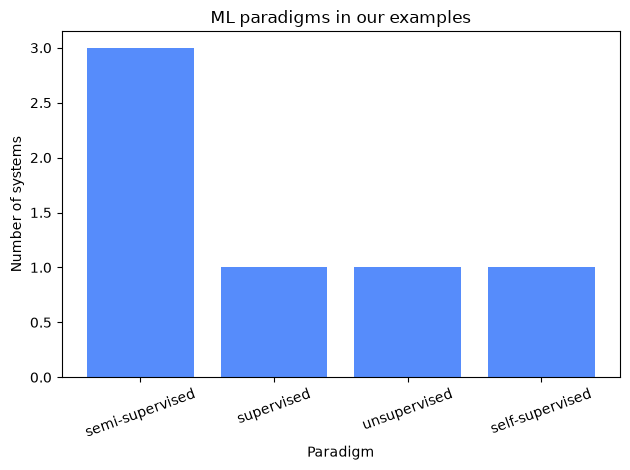

In [15]:
# === Task 3: counts & bar chart ==========================================

paradigm_counts = systems["paradigm"].value_counts()

print("Counts by paradigm:")
print(paradigm_counts)

# Simple check: total count should equal number of systems
assert paradigm_counts.sum() == len(systems)

# Plot a bar chart
fig, ax = plt.subplots()
ax.bar(paradigm_counts.index, paradigm_counts.values)
ax.set_xlabel("Paradigm")
ax.set_ylabel("Number of systems")
ax.set_title("ML paradigms in our examples")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Stretch tasks (optional)

If you finish Tasks 1–3 early, try one or more of these:

1. **Add your own system.**  
   - Append a new row to the `systems` DataFrame with `system_name`, `description`, `has_labels`, `stakes`, and `paradigm`.  
   - Re-run the counts & bar chart. Does adding your example change the overall story?

2. **Add a column for data source.**  
   - For each system, add a `data_source` column (e.g., "user interactions", "sensors", "logs").  
   - Are certain paradigms more tied to certain data sources?

3. **Interpretability vs black-box.**  
   - Add a boolean column `needs_interpretability` indicating whether you’d demand a **transparent / explainable** model.  
   - Which systems feel especially unsafe as black boxes?

If you do a stretch task, summarize what you found in the final reflection cell.

In [ ]:
# === Stretch starter code (optional) =====================================

# Example: adding a custom system (uncomment & edit)
# new_row = {
#     "system_name": "Your example here",
#     "description": "What it does...",
#     "has_labels": True,
#     "stakes": "medium",
#     "paradigm": "supervised",
# }
# systems = pd.concat([systems, pd.DataFrame([new_row])], ignore_index=True)

# TODO: extend this with one of the stretch ideas.

## Reflection

Answer these in your own words (bullet points or short sentences are fine):

1. **Which system did you choose as your anchor for this course, and why?**
- `Language model autocomplete`. Sometimes I feel that ChatGPT can my mind when I was typing, I would like to know how it works.

2. **What did labeling paradigms force you to think about?**  
   (e.g., where labels come from, how training objectives are defined, how feedback is obtained.)
- In the classroom, teachers tell students how to determine an integer is even or odd. The teacher gives some examples, then asks the students to find odd numbers. If the student's answer is wrong, the teacher will tell the student that they are wrong.

3. **What did your metric choice *hide* or simplify?**  
   (Is there anything important about the system that accuracy/recall/etc. doesn’t capture?)
- The metric choice simplifies the calculation of the server load.

4. **Looking at the course outline, which upcoming topic do you think will be most relevant to your anchor system?**
- I think Neural networks will be most relevant to my anchor system.